In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_url = (
    "https://raw.githubusercontent.com/"
    "JediNoahMio65/"
    "wearable-heart-rate-manufacturing-quality-dashboard/"
    "main/data/synthetic_manufacturing_data.csv"
)

df = pd.read_csv(csv_url, parse_dates=["build_date"])

print(f"Loaded {len(df):,} synthetic unit records.")
display(df.head())

Loaded 2,400 synthetic unit records.


,unit_id,build_date,production_line,shift,test_station,firmware_version,heart_rate_error_bpm,response_time_seconds,signal_quality_score,test_status,defect_category,rework_required
0,WHRM-00001,2026-07-01,Line A,Day,TS-01,FW-SIM-0.2,0.76,3.81,95.0,Pass,NaN,No
1,WHRM-00002,2026-07-01,Line A,Evening,TS-01,FW-SIM-0.2,4.25,3.77,92.1,Pass,NaN,No
2,WHRM-00003,2026-07-01,Line A,Evening,TS-02,FW-SIM-0.2,3.42,5.00,94.4,Pass,NaN,No
3,WHRM-00004,2026-07-01,Line B,Day,TS-03,FW-SIM-0.2,1.93,4.11,94.2,Pass,NaN,No
4,WHRM-00005,2026-07-01,Line A,Evening,TS-01,FW-SIM-0.2,0.91,5.18,89.0,Fail,Slow response time,Yes


In [2]:
daily_yield = (
    df.assign(passed=df["test_status"].eq("Pass"))
      .groupby("build_date", as_index=False)
      .agg(
          units_tested=("unit_id", "count"),
          first_pass_yield=("passed", "mean"),
          failure_rate=("passed", lambda x: 1 - x.mean())
      )
)

display(
    daily_yield.style.format({
        "first_pass_yield": "{:.1%}",
        "failure_rate": "{:.1%}"
    })
)

,build_date,units_tested,first_pass_yield,failure_rate
0,2026-07-01 00:00:00,89,77.5%,22.5%
1,2026-07-02 00:00:00,89,75.3%,24.7%
2,2026-07-03 00:00:00,89,78.7%,21.3%
3,2026-07-04 00:00:00,89,73.0%,27.0%
4,2026-07-05 00:00:00,89,78.7%,21.3%
5,2026-07-06 00:00:00,89,77.5%,22.5%
6,2026-07-07 00:00:00,88,71.6%,28.4%
7,2026-07-08 00:00:00,89,77.5%,22.5%
8,2026-07-09 00:00:00,89,83.1%,16.9%
9,2026-07-10 00:00:00,89,68.5%,31.5%


In [7]:
daily_yield = daily_yield.query("units_tested >= 20").copy()

print(
    f"Daily trend includes {len(daily_yield)} dates with at least "
    f"20 units tested."
)

Daily trend includes 27 dates with at least 20 units tested.


In [3]:
firmware_summary = (
    df.assign(passed=df["test_status"].eq("Pass"))
      .groupby("firmware_version", as_index=False)
      .agg(
          units_tested=("unit_id", "count"),
          first_pass_yield=("passed", "mean"),
          mean_response_time_s=("response_time_seconds", "mean"),
          median_response_time_s=("response_time_seconds", "median"),
          mean_hr_error_bpm=("heart_rate_error_bpm", "mean"),
          mean_signal_quality=("signal_quality_score", "mean")
      )
      .sort_values("firmware_version")
)

display(
    firmware_summary.style.format({
        "first_pass_yield": "{:.1%}",
        "mean_response_time_s": "{:.2f}",
        "median_response_time_s": "{:.2f}",
        "mean_hr_error_bpm": "{:.2f}",
        "mean_signal_quality": "{:.1f}"
    })
)

,firmware_version,units_tested,first_pass_yield,mean_response_time_s,median_response_time_s,mean_hr_error_bpm,mean_signal_quality
0,FW-SIM-0.2,1244,75.1%,4.32,4.31,2.63,90.6
1,FW-SIM-0.3,1156,84.1%,3.84,3.85,2.60,90.5


In [4]:
USL_RESPONSE_TIME = 5.0
USL_HR_ERROR = 5.0

def upper_capability(series, upper_spec_limit):
    mean = series.mean()
    std_dev = series.std(ddof=1)
    cpu = (upper_spec_limit - mean) / (3 * std_dev)
    return mean, std_dev, cpu

response_mean, response_std, response_cpu = upper_capability(
    df["response_time_seconds"],
    USL_RESPONSE_TIME
)

hr_error_mean, hr_error_std, hr_error_cpu = upper_capability(
    df["heart_rate_error_bpm"],
    USL_HR_ERROR
)

capability_summary = pd.DataFrame({
    "Metric": ["Response time", "Heart-rate error"],
    "Upper specification limit": [USL_RESPONSE_TIME, USL_HR_ERROR],
    "Mean": [response_mean, hr_error_mean],
    "Standard deviation": [response_std, hr_error_std],
    "Simulated Cpu": [response_cpu, hr_error_cpu]
})

display(
    capability_summary.style.format({
        "Upper specification limit": "{:.2f}",
        "Mean": "{:.2f}",
        "Standard deviation": "{:.2f}",
        "Simulated Cpu": "{:.2f}"
    })
)

print(
    "Note: These are simulated screening metrics based on overall data. "
    "They are not formal Cp/Cpk qualification results."
)

,Metric,Upper specification limit,Mean,Standard deviation,Simulated Cpu
0,Response time,5.00,4.09,0.67,0.45
1,Heart-rate error,5.00,2.62,1.33,0.60


Note: These are simulated screening metrics based on overall data. They are not formal Cp/Cpk qualification results.


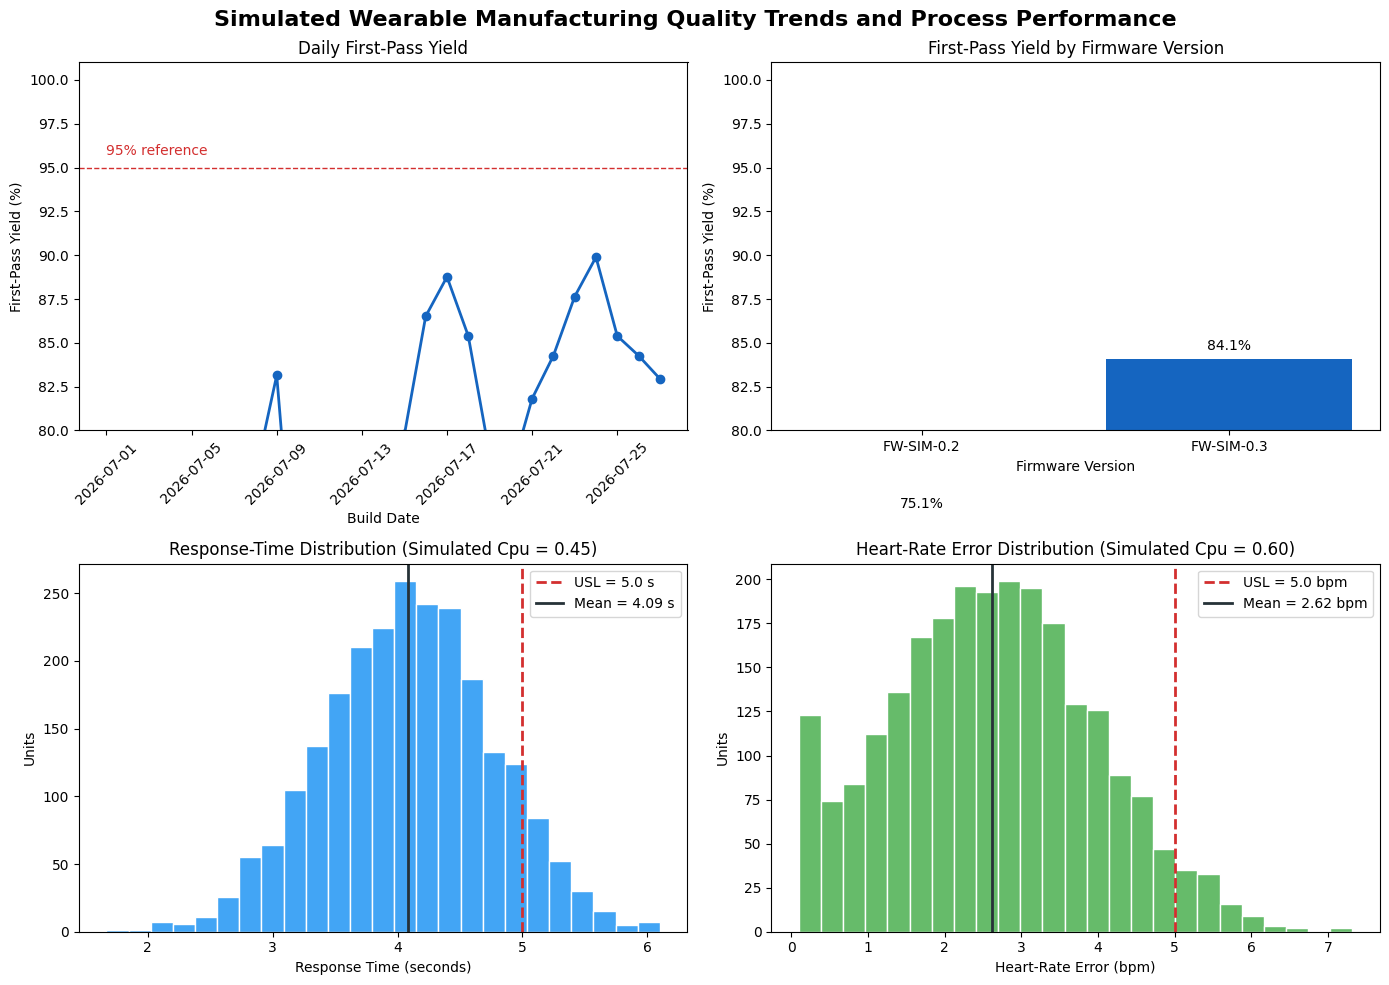

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Simulated Wearable Manufacturing Quality Trends and Process Performance",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].plot(
    daily_yield["build_date"],
    daily_yield["first_pass_yield"] * 100,
    color="#1565C0",
    marker="o",
    linewidth=2
)
axes[0, 0].axhline(95, color="#D32F2F", linestyle="--", linewidth=1)
axes[0, 0].set_title("Daily First-Pass Yield")
axes[0, 0].set_xlabel("Build Date")
axes[0, 0].set_ylabel("First-Pass Yield (%)")
axes[0, 0].set_ylim(80, 101)
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].text(
    daily_yield["build_date"].iloc[0],
    95.7,
    "95% reference",
    color="#D32F2F"
)

firmware_plot = firmware_summary.copy()

axes[0, 1].bar(
    firmware_plot["firmware_version"],
    firmware_plot["first_pass_yield"] * 100,
    color=["#90CAF9", "#1565C0"]
)
axes[0, 1].set_title("First-Pass Yield by Firmware Version")
axes[0, 1].set_xlabel("Firmware Version")
axes[0, 1].set_ylabel("First-Pass Yield (%)")
axes[0, 1].set_ylim(80, 101)

for index, value in enumerate(firmware_plot["first_pass_yield"] * 100):
    axes[0, 1].text(index, value + 0.5, f"{value:.1f}%", ha="center")

axes[1, 0].hist(
    df["response_time_seconds"],
    bins=25,
    color="#42A5F5",
    edgecolor="white"
)
axes[1, 0].axvline(
    USL_RESPONSE_TIME,
    color="#D32F2F",
    linestyle="--",
    linewidth=2,
    label="USL = 5.0 s"
)
axes[1, 0].axvline(
    response_mean,
    color="#263238",
    linestyle="-",
    linewidth=2,
    label=f"Mean = {response_mean:.2f} s"
)
axes[1, 0].set_title(f"Response-Time Distribution (Simulated Cpu = {response_cpu:.2f})")
axes[1, 0].set_xlabel("Response Time (seconds)")
axes[1, 0].set_ylabel("Units")
axes[1, 0].legend()

axes[1, 1].hist(
    df["heart_rate_error_bpm"],
    bins=25,
    color="#66BB6A",
    edgecolor="white"
)
axes[1, 1].axvline(
    USL_HR_ERROR,
    color="#D32F2F",
    linestyle="--",
    linewidth=2,
    label="USL = 5.0 bpm"
)
axes[1, 1].axvline(
    hr_error_mean,
    color="#263238",
    linestyle="-",
    linewidth=2,
    label=f"Mean = {hr_error_mean:.2f} bpm"
)
axes[1, 1].set_title(f"Heart-Rate Error Distribution (Simulated Cpu = {hr_error_cpu:.2f})")
axes[1, 1].set_xlabel("Heart-Rate Error (bpm)")
axes[1, 1].set_ylabel("Units")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(
    "quality_trends_and_process_performance.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [9]:
best_firmware = firmware_summary.loc[
    firmware_summary["first_pass_yield"].idxmax()
]

first_week_yield = daily_yield.iloc[:7]["first_pass_yield"].mean()
last_week_yield = daily_yield.iloc[-7:]["first_pass_yield"].mean()

print("SIMULATED QUALITY FINDINGS")
print(
    f"- Average FPY during the first 7 build days: {first_week_yield:.1%}."
)
print(
    f"- Average FPY during the final 7 build days: {last_week_yield:.1%}."
)
print(
    f"- Highest simulated firmware FPY: {best_firmware['firmware_version']} "
    f"at {best_firmware['first_pass_yield']:.1%}."
)
print(
    f"- Response-time mean: {response_mean:.2f} s; "
    f"simulated Cpu: {response_cpu:.2f}."
)
print(
    f"- Heart-rate error mean: {hr_error_mean:.2f} bpm; "
    f"simulated Cpu: {hr_error_cpu:.2f}."
)
print(
    "- Interpretation: results are fictional educational examples and "
    "not evidence of production-process capability or device performance."
)

SIMULATED QUALITY FINDINGS
- Average FPY during the first 7 build days: 76.0%.
- Average FPY during the final 7 build days: 85.2%.
- Highest simulated firmware FPY: FW-SIM-0.3 at 84.1%.
- Response-time mean: 4.09 s; simulated Cpu: 0.45.
- Heart-rate error mean: 2.62 bpm; simulated Cpu: 0.60.
- Interpretation: results are fictional educational examples and not evidence of production-process capability or device performance.
